# Water Usage Analysis

In [1]:
import logging
import pandas as pd
from scipy.stats import norm
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Replace with your file path
df = pd.read_stata("../clean.dta")

Data Description: the experimental subjects were “residential customers who lived in their homes from May 2006 to April 2007 and used at least 20,000 gallons during the 2006 summer watering season (about 80 percent of the population).” (p.363) Mailings that encouraged water conservation were sent to approximately 11,700 households, with roughly 71,800 households serving as controls.[1]  Outcomes were measured using the utility company’s records of water usage at each address.

Note that the main focus is on the control group treatment==4 and the social norms treatment treatment==3.

## Process and save the clean data

In [3]:
for feature in df.head():
    print(feature, df.loc[0, feature])

prem 100004
route 909
_6_jun 3
_6_jul 4
_6_aug 6
_6_sep 7
_6_oct 6
_6_nov 8
_6_dec 7.0
_7_jan 9.0
_7_feb 8.0
_7_mar 4
_7_apr 5
jun_oct 26.0
jun_oct_report 26000.0
jun_sep 20.0
jul_oct 23.0
aug_oct 19.0
sep_oct 13.0
aug_sep 13.0
jul_sep 17.0
percentile 0.3732685
percentile_ 37.32685
percent_report 36.0
apr07_3x 5.0
may07_3x 6.0
jun07_3x 5.0
jul07_3x 5.0
aug07_3x 5.0
sep07_3x 6.0
oct07_3x 4.0
nov07_3x 6.0
zero_values_summer 0
i 52143.5
n 139693.0
group_1 4
jun06 3
jul06 4
aug06 6
sep06 7
oct06 6
nov06 8
dec06 7.0
jan07 9.0
feb07 8.0
mar07 4
apr07 5
Percentile_ 37.32685
treat2 0.0
_merge1 1
treat3 0.0
_merge2 1
treat1 0.0
_merge3 1
group 4.0
apr07_2 5.0
may07_2 6.0
jun07_2 5.0
jul07_2 5.0
aug07_2 5.0
sep07_2 6.0
apr_sep07_2 32.0
_MERGE 3
ev_apr07 0.0
ev_apr07_2 Don't difference on values
ev_apr07_3 >0 old-database, greater new-database
ev_street 1.0
d_ev_street 0.0
ev_lastname 1.0
d_ev_lastname 0.0
_MERGE2 3
apr07_3 5.0
may07_3 6.0
jun07_3 5.0
jul07_3 5.0
aug07_3 5.0
sep07_3 6.0
oct07_3 4

In [4]:
def select_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Selects and renames a subset of experimental variables from the DataFrame if present.
    """
    candidate_columns = [
        # Treatment assignment
        "treat1", "treat2", "treat3",

        # Pre-treatment water use
        "h_pc2_water_2006",
        "h_pc2_apr_may_07",

        # Post-treatment water use (outcome)
        "summer_07", "summer_08", "summer_09",

        # Fair market value of house
        "h_pc2_fmv",

        # Owner/renter status
        "h_pc2_renter",

        # Age of home (year built)
        "h_pc2_yblt",

        # Demographics: % White and % higher degree
        "h_pc2_white", "h_pc2_higheduc",

        # Treatment–covariate interactions
        "t1_h_pc2_fmv", "t2_h_pc2_fmv", "t3_h_pc2_fmv",
        "t1_h_pc2_renter", "t2_h_pc2_renter", "t3_h_pc2_renter",
        "t1_h_pc2_yblt", "t2_h_pc2_yblt", "t3_h_pc2_yblt",
        "t1_h_pc2_white", "t2_h_pc2_white", "t3_h_pc2_white",
        "t1_h_pc2_higheduc", "t2_h_pc2_higheduc", "t3_h_pc2_higheduc",
        "t1_h_pc2_water_2006", "t2_h_pc2_water_2006", "t3_h_pc2_water_2006",
        "t1_h_pc2_apr_may_07", "t2_h_pc2_apr_may_07", "t3_h_pc2_apr_may_07",
    ]

    existing_cols = [col for col in candidate_columns if col in df.columns]
    missing_cols = [col for col in candidate_columns if col not in df.columns]
    if missing_cols:
        logging.info("Skipping missing columns: %s", ", ".join(missing_cols))

    df_sub = df[existing_cols].copy()

    # Base renames
    rename_map = {
        "h_pc2_water_2006": "summer2006",
        "h_pc2_apr_may_07": "aprmay2007",
        "summer_07": "summer2007",
        "summer_08": "summer2008",
        "summer_09": "summer2009",
        "h_pc2_fmv": "home_value",
        "h_pc2_renter": "is_renter",
        "h_pc2_yblt": "year_built",
        "h_pc2_white": "pct_white",
        "h_pc2_higheduc": "pct_college",
    }

    # Interaction variable renames
    interaction_base = {
        "fmv": "home_value",
        "renter": "is_renter",
        "yblt": "year_built",
        "white": "pct_white",
        "higheduc": "pct_college",
        "water_2006": "summer2006",
        "apr_may_07": "aprmay2007",
    }

    for col in df_sub.columns:
        if col.startswith(("t1_", "t2_", "t3_")) and "_h_pc2_" in col:
            for old, new in interaction_base.items():
                if old in col:
                    rename_map[col] = col.replace(f"_h_pc2_{old}", f"_{new}")
                    break

    df_sub.rename(columns=rename_map, inplace=True)
    return df_sub

In [5]:
subset_df = select_columns(df)
subset_df.to_csv("water_data.csv", index=False)

# Load the processed data

In [6]:
water_df = pd.read_csv("water_data.csv")

In [7]:
rng = np.random.default_rng(42)

Focus on treatment 3 and control group

In [8]:
filtered_df = water_df.loc[
    (water_df['treat3'] == 1) |
    (water_df['treat1'] == 0) &
    (water_df['treat2'] == 0) &
    (water_df['treat3'] == 0), :
]
filtered_df = filtered_df.drop(
    columns=['treat1', 'treat2','summer2007', 'summer2009'] +
    [col for col in filtered_df.columns if 't1' in col or 't2' in col or "t3_" in col]
).rename(columns={'treat3': 'treat'})

In [9]:
filtered_df.columns

Index(['treat', 'summer2006', 'aprmay2007', 'summer2008', 'home_value',
       'is_renter', 'year_built', 'pct_white', 'pct_college'],
      dtype='object')

## Check missing values

Check missing values and drop any rows with missing data

In [10]:
filtered_df.isnull().mean()

treat          0.000000
summer2006     0.000000
aprmay2007     0.000000
summer2008     0.000000
home_value     0.025912
is_renter      0.103122
year_built     0.029885
pct_white      0.103122
pct_college    0.103122
dtype: float64

In [11]:
filtered_df = filtered_df.dropna()

In [12]:
filtered_df.columns

Index(['treat', 'summer2006', 'aprmay2007', 'summer2008', 'home_value',
       'is_renter', 'year_built', 'pct_white', 'pct_college'],
      dtype='object')

## Compute ATE with the full data

In [13]:
y1 = filtered_df.loc[filtered_df.treat == 1, "summer2008"].to_numpy(float)
y0 = filtered_df.loc[filtered_df.treat == 0, "summer2008"].to_numpy(float)

# Point estimate
theta = y1.mean() - y0.mean()

# Plug-in variance
var_theta = y1.var(ddof=1) / y1.size + y0.var(ddof=1) / y0.size
se_theta = np.sqrt(var_theta)

# 95% CI (Normal approximation)
lower_bound = theta - 1.96 * se_theta
upper_bound = theta + 1.96 * se_theta

print(f"Point estimate of θ: {theta:.4f}")
print(f"Variance: {var_theta:.6f}")
print(f"95% Confidence Interval: [{lower_bound:.4f}, {upper_bound:.4f}]")

Point estimate of θ: -0.4783
Variance: 0.037482
95% Confidence Interval: [-0.8577, -0.0988]


## Constructing Experimetnal, Observational and Calibration Estimators

Split the data into 100 equally sized disjoint subsets by stratified sampling: sample the treatment and control groups separately and then combining them.

In [14]:
num_splits = 100

df_treat = filtered_df.loc[filtered_df["treat"] == 1].sample(frac=1, random_state=42).reset_index(drop=True)
df_ctrl  = filtered_df.loc[filtered_df["treat"] == 0].sample(frac=1, random_state=42).reset_index(drop=True)

t_idx = np.array_split(np.arange(len(df_treat)), num_splits)
c_idx = np.array_split(np.arange(len(df_ctrl)),  num_splits)

subsets = [
    pd.concat([df_treat.iloc[t_idx[i]], df_ctrl.iloc[c_idx[i]]], ignore_index=True)
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
    for i in range(num_splits)
]

### Experimental Design

Assign the first subset as experimental data. Since treatment is randomized, we combine these subsets and compute the ATE and its variance on the pooled sample.

In [15]:
experimental_subsets = subsets[:1]
df_e = pd.concat(experimental_subsets, ignore_index=True)

o1 = df_e.loc[df_e.treat == 1, "summer2008"].to_numpy(float)
o0 = df_e.loc[df_e.treat == 0, "summer2008"].to_numpy(float)

y_e = o1.mean() - o0.mean()
sigma2_e = o1.var(ddof=1) / o1.size + o0.var(ddof=1) / o0.size

print(f"ATE: {y_e:.6f}")
print(f"Var(ATE): {sigma2_e:.6f}")

ATE: -1.402764
Var(ATE): 3.158861


### Observational Design

In [16]:
observational_subsets = subsets[1:]

Define a new propensity score model in which the pre-treatment water use in summer 2006 has a strong positive effect on receiving the treatment.

In [17]:
def e_obs(X, beta):
    z = X @ beta
    z = (z - z.mean()) / (z.std() + 1e-12)
    return 1.0 / (1.0 + np.exp(-z))

covariates = ["summer2006"]
beta = np.array([0.5])

In [18]:
y_obs, sigma2_obs = [], []

for df in observational_subsets:
    X = df[covariates].to_numpy(float)
    p = e_obs(X, beta)

    a = df["treat"].to_numpy(int)
    w = a / np.clip(p, 1e-6, 1 - 1e-6) + (1 - a) / np.clip(1 - p, 1e-6, 1 - 1e-6)
    prob = w / w.sum()

    idx = rng.choice(len(df), size=len(df), replace=True, p=prob)
    df_obs = df.iloc[idx]

    o1 = df_obs.loc[df_obs.treat == 1, "summer2008"].to_numpy(float)
    o0 = df_obs.loc[df_obs.treat == 0, "summer2008"].to_numpy(float)

    y = o1.mean() - o0.mean()
    v = o1.var(ddof=1) / o1.size + o0.var(ddof=1) / o0.size

    y_obs.append(y)
    sigma2_obs.append(v)

y_obs = np.array(y_obs)
sigma2_obs = np.array(sigma2_obs)

print("Observational mean bias is", np.mean(y_obs) - theta)

Observational mean bias is -5.2465532259847425


Apply the illusion model to combine the experimental the observational estimates.
1) Estimate $\sigma^2_b$ by maximizing the marginal likelihood (given in the proof of Theorem 1).

In [19]:
def obj_sigma_b2(sigma_b2, y_obs, sigma2_obs, sigma2_e):
    d = sigma2_obs + sigma_b2
    w = 1.0 / d
    y_tilde = (w @ y_obs) / w.sum()
    term1 = -np.sum((y_obs - y_tilde) ** 2 / d)
    term2 = -np.sum(np.log(d))
    term3 = -np.log(1.0 / sigma2_e + np.sum(w))
    return term1 + term2 + term3

def fit_mmle(y_obs, sigma2_obs, sigma2_e, upper=1e6):
    y_obs = np.asarray(y_obs, dtype=float)
    sigma2_obs = np.asarray(sigma2_obs, dtype=float)
    eps = 1e-12
    sigma2_obs = np.maximum(sigma2_obs, eps)

    res = minimize_scalar(
        lambda s: -obj_sigma_b2(s, y_obs, sigma2_obs, sigma2_e),
        bounds=(0.0, upper),
        method="bounded",
        options={"xatol": 1e-10},
    )
    return res.x, obj_sigma_b2(res.x, y_obs, sigma2_obs, sigma2_e), res

sigma2_b, obj_hat, res = fit_mmle(y_obs, sigma2_obs, sigma2_e)

2) Compute the illusion posterior mean and variance using the estimated $\sigma^2_b$.

In [20]:
illusion_mean = y_e
illusion_var = 1.0 / (
    1.0 / sigma2_e + np.sum(1.0 / (sigma2_obs + sigma2_b))
)

### Calibration Design

In [21]:
calibration_subsets = subsets[1:]

In [22]:
y_n, sigma2_n = [], []

for df in calibration_subsets:
    X = df[covariates].to_numpy(float)
    p = np.clip(e_obs(X, beta), 1e-6, 1 - 1e-6)

    a_tilde = rng.binomial(1, p, size=len(df))

    o = df["summer2008"].to_numpy(float)
    o1 = o[a_tilde == 1]
    o0 = o[a_tilde == 0]

    y = o1.mean() - o0.mean()
    v = o1.var(ddof=1) / o1.size + o0.var(ddof=1) / o0.size

    y_n.append(y)
    sigma2_n.append(v)

y_n = np.array(y_n)
sigma2_n = np.array(sigma2_n)

print("Calibration mean:", np.mean(y_n))
print("Calibration mean variance:", np.mean(sigma2_n))

Calibration mean: 5.686747440845984
Calibration mean variance: 2.030501451107756


Apply the calibrated illusion model to combine the experimental, observational and calibration estimates. We estimate $\mu_b$ and $\sigma^2_b$ with moment estimators.

In [23]:
mu_b = np.mean(y_n)
sigma2_b = np.sum((y_n - mu_b)**2) / (len(y_n) - 1)

# Precision terms
prec_e = 1.0 / sigma2_e
prec_obs = 1.0 / (sigma2_obs + sigma2_b)

# Empirical Bayes posterior mean
EB_post_mean = (
    prec_e * y_e
    + np.sum(prec_obs * (y_obs + mu_b))
) / (
    prec_e + np.sum(prec_obs)
)

# Empirical Bayes posterior variance
EB_post_var = 1.0 / (
    prec_e + np.sum(prec_obs)
)

print(f"EB posterior mean: {EB_post_mean:.6f}")
print(f"EB posterior variance: {EB_post_var:.6f}")

EB posterior mean: -0.368993
EB posterior variance: 0.047729


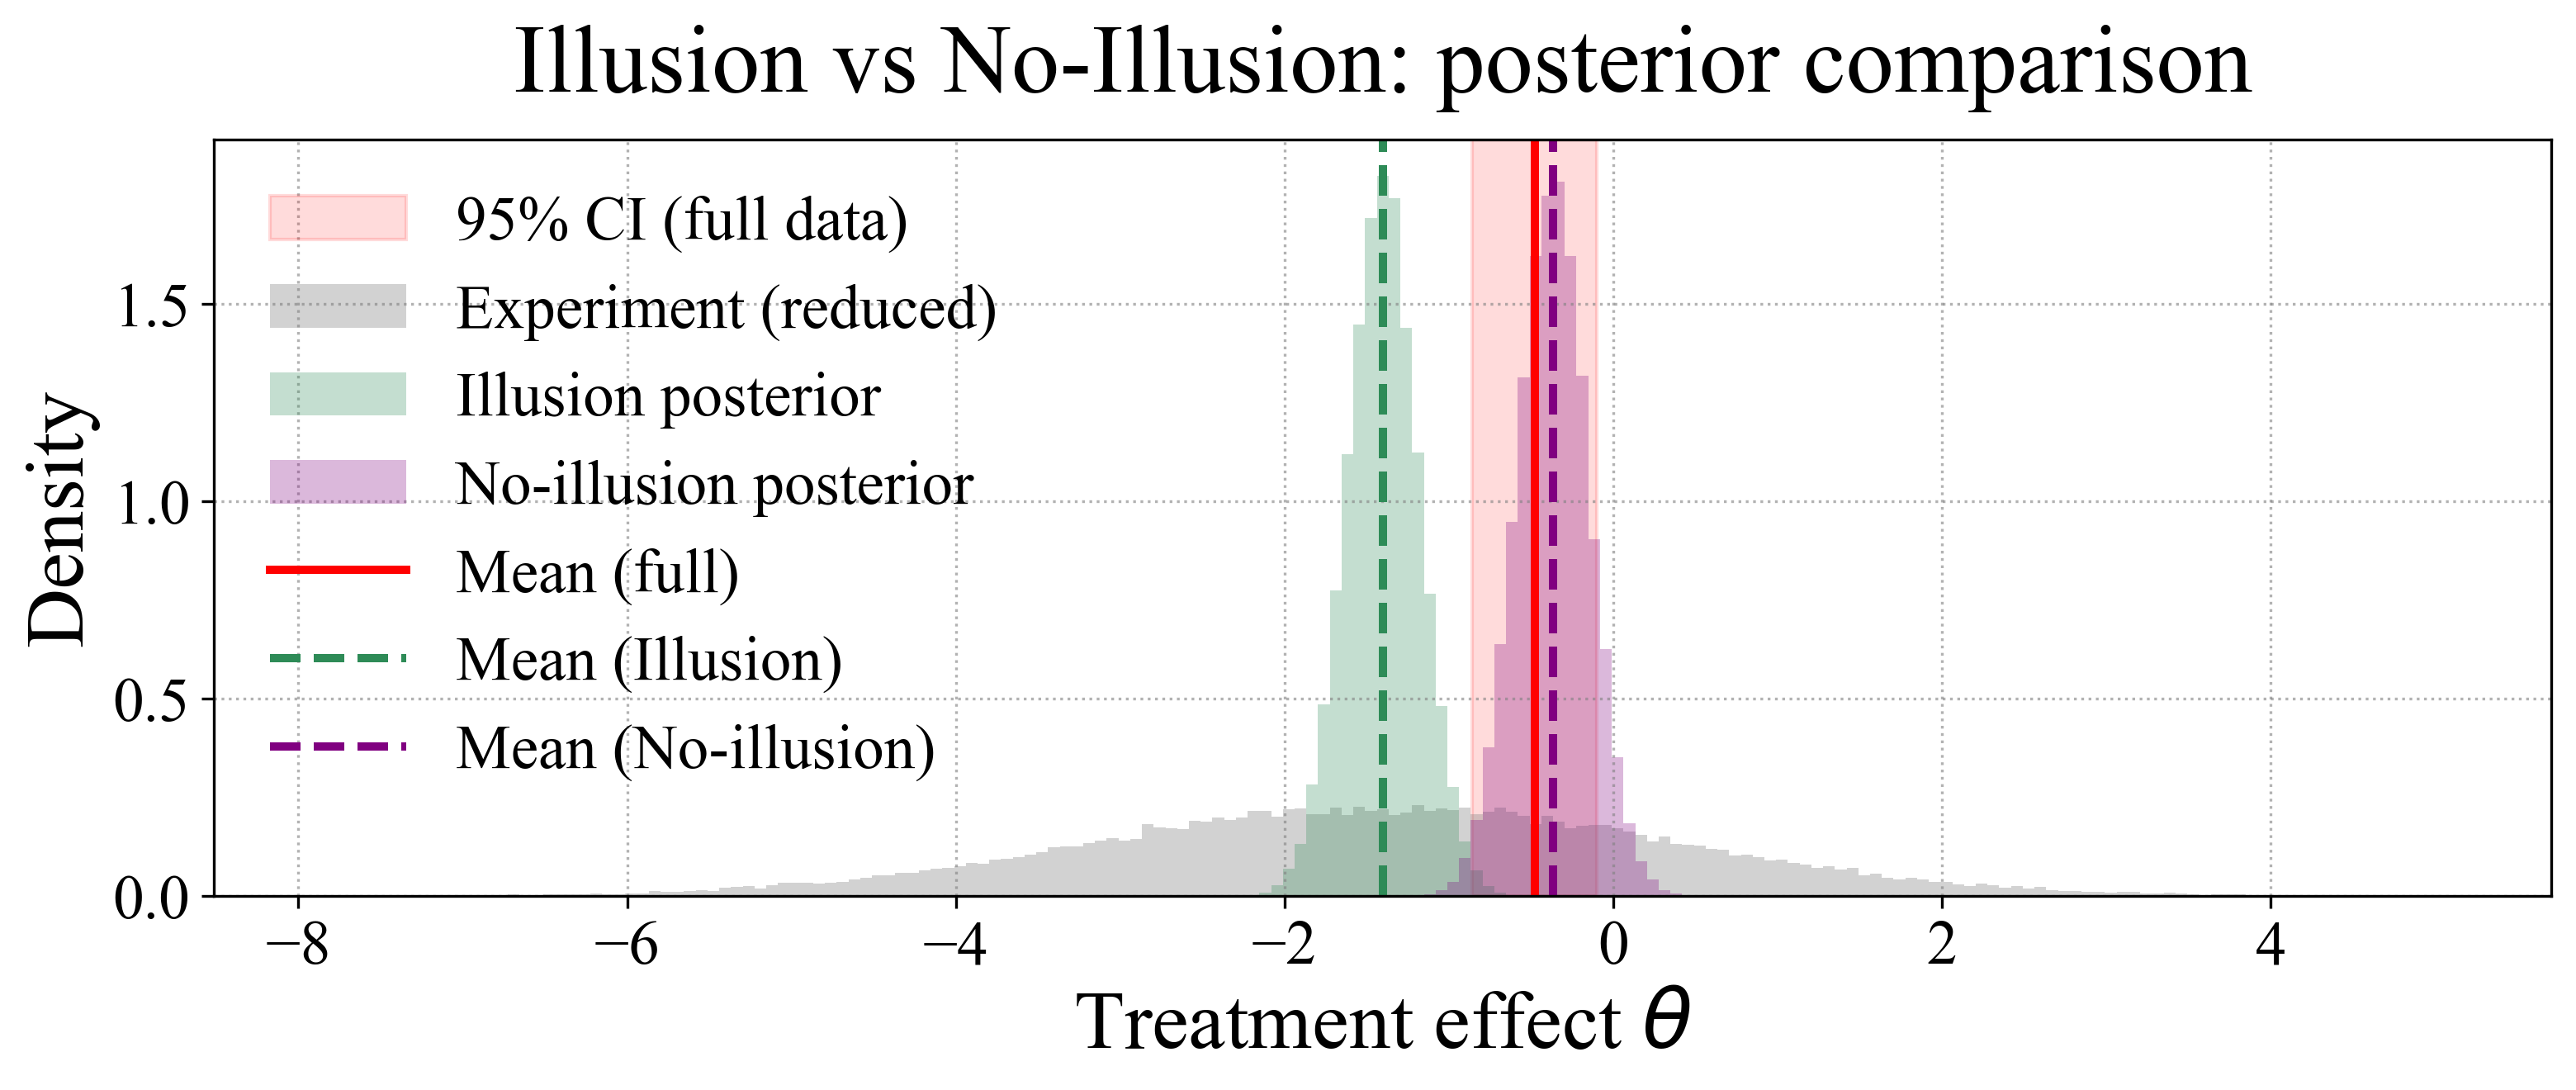

In [24]:
sd_e  = np.sqrt(sigma2_e)
sd_ill = np.sqrt(illusion_var)
sd_EB  = np.sqrt(EB_post_var)

# Plot range
x_lo = min(y_e - 4 * sd_e, illusion_mean - 4 * sd_ill, EB_post_mean - 4 * sd_EB)
x_hi = max(y_e + 4 * sd_e, illusion_mean + 4 * sd_ill, EB_post_mean + 4 * sd_EB)

plt.rcParams.update({
    "font.family": "Times New Roman",
    "axes.titlesize": 28,
    "axes.labelsize": 24,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})

FIGSIZE = (10.5, 4.5)
LW = 2.4
GRID_ALPHA = 0.6

COL_EXP  = "grey"
COL_ILL  = "seagreen"
COL_EB   = "purple"
COL_FULL = "red"

# ----------------------------
# Posterior draws for histograms
# ----------------------------
M = 40000
draw_e   = rng.normal(loc=y_e,          scale=sd_e,   size=M)
draw_ill = rng.normal(loc=illusion_mean, scale=sd_ill, size=M)
draw_EB  = rng.normal(loc=EB_post_mean, scale=sd_EB,  size=M)

# Histogram bins
bins = np.linspace(x_lo, x_hi, 200)

# ----------------------------
# Figure
# ----------------------------
fig, ax = plt.subplots(figsize=FIGSIZE, dpi=300)

# Full-data CI band + mean
ax.axvspan(lower_bound, upper_bound, color=COL_FULL, alpha=0.14, label=r"95% CI (full data)")

# Histograms
ax.hist(draw_e, bins=bins, density=True, alpha=0.35, color=COL_EXP, edgecolor="none",
        label="Experiment (reduced)")
ax.hist(draw_ill, bins=bins, density=True, alpha=0.28, color=COL_ILL, edgecolor="none",
        label="Illusion posterior")
ax.hist(draw_EB, bins=bins, density=True, alpha=0.28, color=COL_EB, edgecolor="none",
        label="No-illusion posterior")

# Posterior means
ax.axvline(theta, color=COL_FULL, linestyle="-", linewidth=LW, label=r"Mean (full)")
ax.axvline(illusion_mean, color=COL_ILL, linestyle="--", linewidth=LW, label=r"Mean (Illusion)")
ax.axvline(EB_post_mean,  color=COL_EB,  linestyle="--", linewidth=LW, label=r"Mean (No-illusion)")


ax.set_xlim(x_lo, x_hi)
ax.set_xlabel(r"Treatment effect $\theta$")
ax.set_ylabel("Density")
ax.set_title("Illusion vs No-Illusion: posterior comparison", pad=14)

ax.grid(True, axis="both", linestyle=":", color="gray", alpha=GRID_ALPHA)
ax.legend(frameon=False, ncol=1, handlelength=2.2, columnspacing=1.2, loc="upper left")

fig.tight_layout()
fig.savefig("illusion_vs_no_illusion.pdf", bbox_inches="tight", dpi=300)
plt.show()
plt.close(fig)

In [25]:
z = 1.96

# -----------------------
# Reduced experimental posterior (Exp1) — baseline
# -----------------------
exp_mean = y_e
exp_var  = sigma2_e
exp_sd   = np.sqrt(exp_var)
exp_lo   = exp_mean - z * exp_sd
exp_hi   = exp_mean + z * exp_sd

# Posterior expected MSE (baseline)
err_exp1 = exp_var + (exp_mean - theta) ** 2
exp_p_in_trueCI = (
    norm.cdf(upper_bound, loc=exp_mean, scale=exp_sd)
    - norm.cdf(lower_bound, loc=exp_mean, scale=exp_sd)
)

# -----------------------
# Illusion posterior
# -----------------------
ill_mean = illusion_mean
ill_var  = illusion_var
ill_sd   = np.sqrt(ill_var)
ill_lo   = ill_mean - z * ill_sd
ill_hi   = ill_mean + z * ill_sd
ill_p_in_trueCI = (
    norm.cdf(upper_bound, loc=ill_mean, scale=ill_sd)
    - norm.cdf(lower_bound, loc=ill_mean, scale=ill_sd)
)

err_ill = ill_var + (ill_mean - theta) ** 2
ill_rel_prec = err_exp1 / err_ill


# -----------------------
# No-illusion (EB calibrated) posterior
# -----------------------
EB_mean = EB_post_mean
EB_var  = EB_post_var
EB_sd   = np.sqrt(EB_var)
EB_lo   = EB_mean - z * EB_sd
EB_hi   = EB_mean + z * EB_sd
EB_p_in_trueCI = (
    norm.cdf(upper_bound, loc=EB_mean, scale=EB_sd)
    - norm.cdf(lower_bound, loc=EB_mean, scale=EB_sd)
)

err_EB = EB_var + (EB_mean - theta) ** 2
EB_rel_prec = err_exp1 / err_EB


# -----------------------
# Full experimental ATE (frequentist CI)
# -----------------------
full_mean = theta
full_lo   = lower_bound
full_hi   = upper_bound

# -----------------------
# Report (rounded to 2 decimals)
# -----------------------
print("=== Experimental (reduced) ===")
print(f"Mean: {exp_mean:.2f}")
print(f"95% CI: [{exp_lo:.2f}, {exp_hi:.2f}]")
print(f"P(theta in true CI): {exp_p_in_trueCI:.2f}")
print(f"Relative precision: {1:.2f}\n")

print("=== Illusion posterior (exp + obs, no calibration) ===")
print(f"Mean: {ill_mean:.2f}")
print(f"95% CI: [{ill_lo:.2f}, {ill_hi:.2f}]")
print(f"P(theta in true CI): {ill_p_in_trueCI:.4f}")
print(f"Relative precision: {ill_rel_prec:.2f}\n")

print("=== No-illusion posterior (EB with calibration) ===")
print(f"Mean: {EB_mean:.2f}")
print(f"95% CI: [{EB_lo:.2f}, {EB_hi:.2f}]")
print(f"P(theta in true CI): {EB_p_in_trueCI:.2f}")
print(f"Relative precision: {EB_rel_prec:.2f}\n")

print("=== Experiment (full sample) ===")
print(f"Mean: {full_mean:.2f}")
print(f"95% CI: [{full_lo:.2f}, {full_hi:.2f}]")
print("P(theta > 0): NA")
print(f"Relative precision: {err_exp1/var_theta:.2f}\n")

=== Experimental (reduced) ===
Mean: -1.40
95% CI: [-4.89, 2.08]
P(theta in true CI): 0.15
Relative precision: 1.00

=== Illusion posterior (exp + obs, no calibration) ===
Mean: -1.40
95% CI: [-1.84, -0.97]
P(theta in true CI): 0.0068
Relative precision: 4.44

=== No-illusion posterior (EB with calibration) ===
Mean: -0.37
95% CI: [-0.80, 0.06]
P(theta in true CI): 0.88
Relative precision: 67.27

=== Experiment (full sample) ===
Mean: -0.48
95% CI: [-0.86, -0.10]
P(theta > 0): NA
Relative precision: 107.08

